In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from src.utils.paths import load_config

In [2]:
config = load_config(PROJECT_ROOT / "config.yaml")

model_summary_path = PROJECT_ROOT / "outputs" / "metrics" / "model_summary.csv"
comparison_grid_path = PROJECT_ROOT / config["reports"]["model_comparison_grid"]
nearest_grid_path = PROJECT_ROOT / config["reports"]["nearest_neighbor_examples"]
nearest_csv_path = PROJECT_ROOT / "outputs" / "metrics" / "nearest_neighbor_distances.csv"

vae_log_path = PROJECT_ROOT / "runs" / "vae" / "training_log.csv"
dcgan_log_path = PROJECT_ROOT / "runs" / "dcgan" / "training_log.csv"
diffusion_log_path = PROJECT_ROOT / "runs" / "diffusion" / "training_log.csv"

In [3]:
model_summary = pd.read_csv(model_summary_path)
display(model_summary)

,model,epochs,final_train_loss,final_val_loss,training_behaviour,visual_quality,main_strength,main_limitation
0,VAE,30,460.996294,461.9399,Stable,Low-Medium,Stable latent-space baseline,Blurry generated outputs
1,Tuned DCGAN,30,3.269669,NaN,Adversarial and less stable,Medium-High,Sharper and more textured samples than VAE,GAN artifacts and late training instability
2,Diffusion,30,0.018378,NaN,Stable,High,Best visual quality and diversity,Slower sampling and heavier training


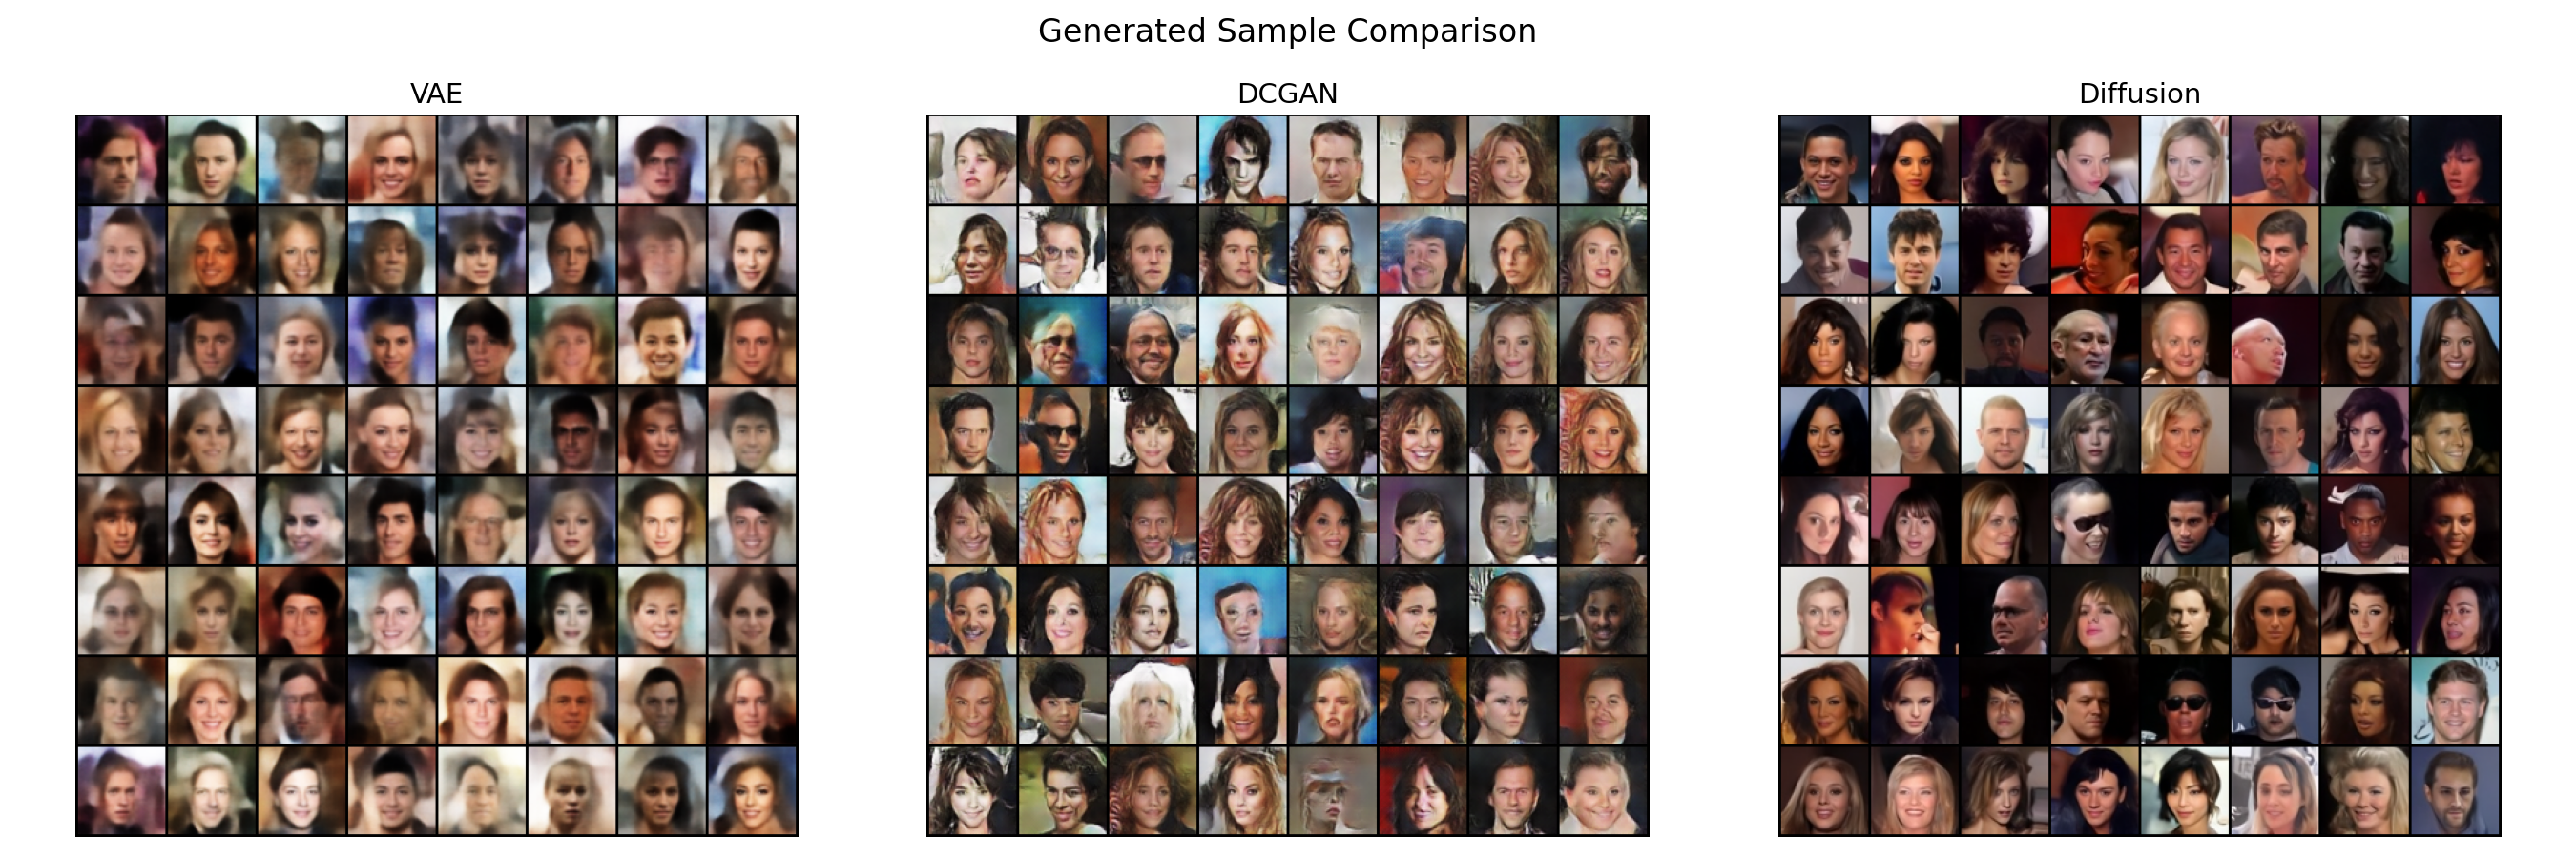

In [4]:
if comparison_grid_path.exists():
    display(Image.open(comparison_grid_path))
else:
    print("Comparison grid not found:", comparison_grid_path)

## Generated Sample Comparison

The generated sample comparison shows a clear progression across model families.

The VAE produces smooth and face-like samples, but the outputs are blurry and lack fine facial detail. The tuned DCGAN produces sharper and more textured images, but some samples contain visible artifacts and the adversarial training process is less stable. The diffusion model produces the strongest visual results, with clearer facial structure, more realistic colour variation, and greater diversity across generated faces.

This supports the main finding of the project:

- VAE is stable but blurry
- DCGAN is sharper but unstable
- Diffusion gives the best overall image quality

In [5]:
vae_log = pd.read_csv(vae_log_path)
dcgan_log = pd.read_csv(dcgan_log_path)
diffusion_log = pd.read_csv(diffusion_log_path)

display(vae_log.tail())
display(dcgan_log.tail())
display(diffusion_log.tail())

,epoch,train_total_loss,train_recon_loss,train_kl_loss,val_total_loss,val_recon_loss,val_kl_loss
25,26,463.670283,315.241932,148.428351,463.892666,314.908302,148.984364
26,27,462.868098,314.465724,148.402374,463.175284,314.582141,148.593144
27,28,462.261499,313.960504,148.300995,464.562998,316.530765,148.032233
28,29,461.474755,313.234190,148.240565,461.455938,313.637891,147.818047
29,30,460.996294,312.784998,148.211296,461.939900,314.168200,147.771700


,epoch,loss_d,loss_g,d_real,d_fake,instance_noise_std,generator_lr,discriminator_lr,real_label_smooth
25,26,0.682224,1.047618,0.757523,0.141458,0.006897,0.0002,0.0001,0.9
26,27,0.651838,1.469956,0.763974,0.135758,0.005172,0.0002,0.0001,0.9
27,28,0.604022,2.272548,0.782335,0.117097,0.003448,0.0002,0.0001,0.9
28,29,0.593923,2.855870,0.792070,0.107506,0.001724,0.0002,0.0001,0.9
29,30,0.538079,3.269669,0.814938,0.084887,0.000000,0.0002,0.0001,0.9


,epoch,train_loss,learning_rate,timesteps,inference_steps
25,26,0.018367,0.0001,1000,50
26,27,0.018186,0.0001,1000,50
27,28,0.018398,0.0001,1000,50
28,29,0.018355,0.0001,1000,50
29,30,0.018378,0.0001,1000,50


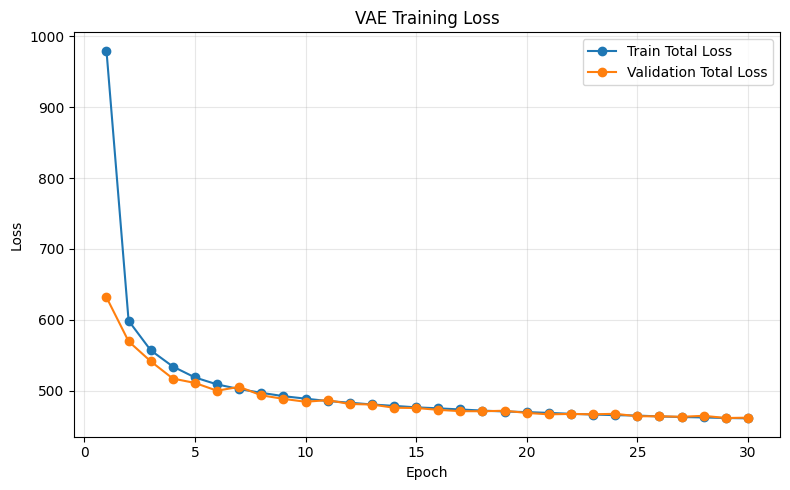

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(vae_log["epoch"], vae_log["train_total_loss"], marker="o", label="Train Total Loss")
plt.plot(vae_log["epoch"], vae_log["val_total_loss"], marker="o", label="Validation Total Loss")

plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

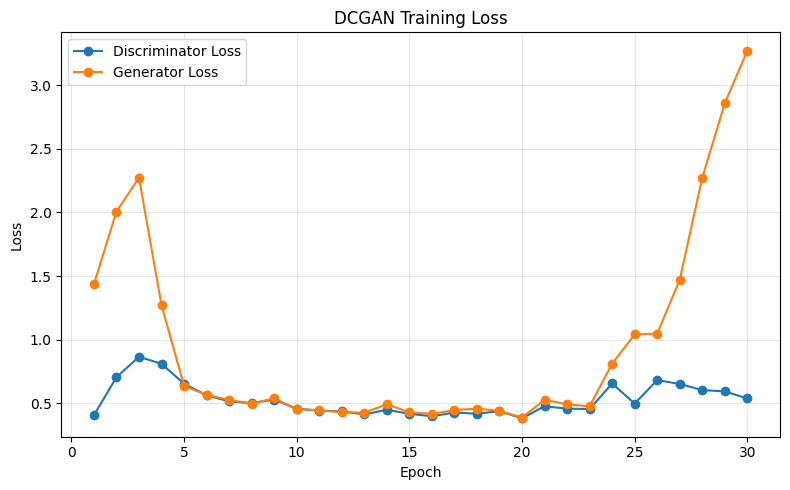

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(dcgan_log["epoch"], dcgan_log["loss_d"], marker="o", label="Discriminator Loss")
plt.plot(dcgan_log["epoch"], dcgan_log["loss_g"], marker="o", label="Generator Loss")

plt.title("DCGAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

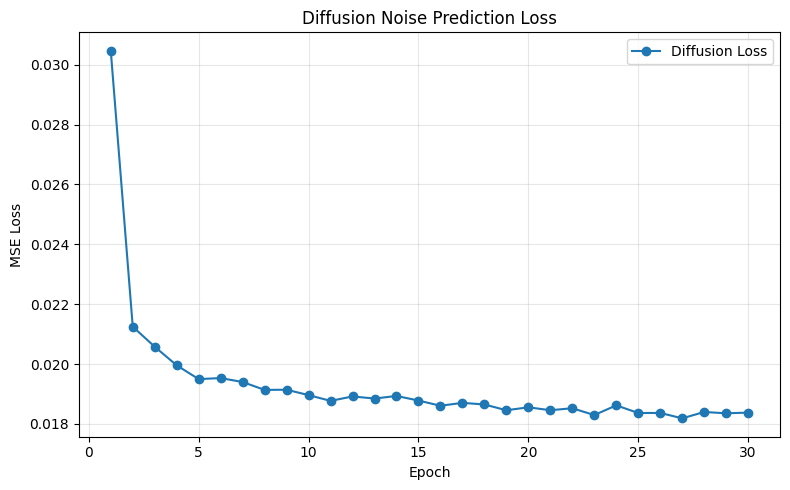

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(diffusion_log["epoch"], diffusion_log["train_loss"], marker="o", label="Diffusion Loss")

plt.title("Diffusion Noise Prediction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Training Behaviour Comparison

The VAE showed the smoothest and most predictable training behaviour, with both training and validation losses decreasing steadily. This reflects the stability of reconstruction-based learning.

The DCGAN showed less stable behaviour because the generator and discriminator were trained adversarially. The tuned DCGAN improved over the first run, but the generator loss increased again near the final epochs, showing that the discriminator became stronger.

The diffusion model showed stable training behaviour. Its noise-prediction loss decreased early and then stabilised, suggesting that the U-Net learned the denoising task effectively.

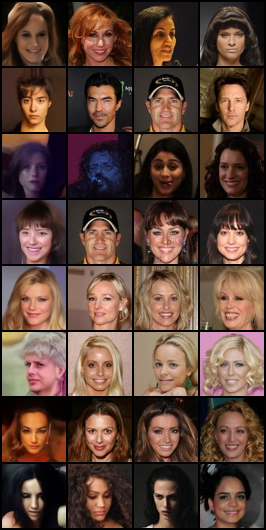

In [9]:
if nearest_grid_path.exists():
    display(Image.open(nearest_grid_path))
else:
    print("Nearest-neighbour grid not found:", nearest_grid_path)

In [10]:
if nearest_csv_path.exists():
    nn_df = pd.read_csv(nearest_csv_path)
    display(nn_df.head(20))
    display(nn_df.groupby("generated_index")["distance"].min().describe())
else:
    print("Nearest-neighbour CSV not found:", nearest_csv_path)

,generated_index,neighbor_rank,real_image_path,distance
0,0,1,E:\celeba-generative-comparison\data\processed...,3.728182
1,0,2,E:\celeba-generative-comparison\data\processed...,3.759347
2,0,3,E:\celeba-generative-comparison\data\processed...,3.877415
3,1,1,E:\celeba-generative-comparison\data\processed...,2.995783
4,1,2,E:\celeba-generative-comparison\data\processed...,3.251882
5,1,3,E:\celeba-generative-comparison\data\processed...,3.261345
6,2,1,E:\celeba-generative-comparison\data\processed...,3.701604
7,2,2,E:\celeba-generative-comparison\data\processed...,3.921798
8,2,3,E:\celeba-generative-comparison\data\processed...,3.973693
9,3,1,E:\celeba-generative-comparison\data\processed...,3.007271


count    8.000000
mean     3.600896
std      0.636607
min      2.995783
25%      3.230362
50%      3.533563
75%      3.708248
max      5.002481
Name: distance, dtype: float64

## Nearest-Neighbour Check

The nearest-neighbour check compares generated diffusion samples with visually similar real training images. This is important because CelebA contains real human face images, and the project should check whether the model appears to copy specific training samples.

The nearest-neighbour examples should be interpreted as a qualitative memorisation check rather than a perfect identity test. Pixel-space nearest neighbours can find images with similar colour, lighting, pose, or background, but they do not prove identity-level similarity.

Based on visual inspection, the generated images should not be exact copies of the nearest real images. Instead, the comparison helps show whether the diffusion model is producing new synthetic samples while still matching the broad CelebA face distribution.